<a href="https://colab.research.google.com/github/beyzanurkeles/Medical-Imaging-Tumor-Segmentation-Image-Processing-/blob/main/ISPY_nnUNet_v2_nnUNet_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

nnUNet baseline 400 veri

In [ ]:
# gpu_info = !nvidia-smi
# gpu_info = '\n'.join(gpu_info)
# if gpu_info.find('failed') >= 0:
#   print('Not connected to a GPU')
# else:
#   print(gpu_info)

Google Drive’ı bağlama ✅

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Kütüphane kurulumu ✅

Gereksiz/çakışan paketleri kaldırma
(önceden yüklenmiş nnUNet veya mmcv paketleri varsa temizler)

In [ ]:
!pip uninstall -y nnunet nnunetv2 mmcv mmcv-full mmdet openmim || true


pip / wheel / setuptools güncelleme ✅

---



In [ ]:
!pip install --upgrade pip wheel setuptools


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.6 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [ ]:
# ================================
# 4. nnU-Net için gerekli kütüphaneler (güncel)
# - nibabel: .nii.gz medikal görüntüler
# - batchgeneratorsv2: yeni augmentasyon altyapısı (nnU-Net >= v2.5 ile uyumlu)
# - SimpleITK, scikit-image, scikit-learn: görüntü işleme / preprocess
# - pandas, tqdm, matplotlib: raporlama, loglama
# ================================
!pip install nibabel batchgeneratorsv2 SimpleITK scikit-image scikit-learn pandas tqdm matplotlib


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 146.1 MB/s  0:00:00
  Created wheel for batchgeneratorsv2: filename=batchgeneratorsv2-0.3.0-py3-none-any.whl size=65215 sha256=4f3616cc3e954aab9b922a56c4537e4ac65c6aad8a15627f273d150c25acd6c5
  Stored in directory: /root/.cache/pip/wheels/9d/99/a0/1224a58f286be9fedbdb256d41e782a63b5ecab743e92ed302
  DEPRECATION: Building 'batchgenerators' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'batchgenerators'. Discussion can be found at https://github.com/pypa/pip/issues

PyTorch kurulumu

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118


Kütüphane Kontrolu

In [ ]:
# Kontrol
import nibabel as nib
print("Nibabel version:", nib.__version__)

import batchgenerators
from batchgenerators.dataloading.multi_threaded_augmenter import MultiThreadedAugmenter

print("Batchgenerators OK ✅")

Nibabel version: 5.3.2
Batchgenerators OK ✅


In [ ]:
import torch
print("Torch version:", torch.__version__)
print("CUDA build     :", torch.version.cuda)
print("CUDA available :", torch.cuda.is_available())
print("GPU count      :", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name       :", torch.cuda.get_device_name(0))

Torch version: 2.8.0+cu126
CUDA build     : 12.6
CUDA available : True
GPU count      : 1
GPU name       : Tesla T4


nnUNet v2 kodunu klonla

In [ ]:
# güvenli köke dön
%cd /content

# varsa eski klasörü temizle (önceki denemelerden kalma olabilir)
!rm -rf /content/nnUNet

# klonla
!git clone https://github.com/MIC-DKFZ/nnUNet.git /content/nnUNet
%cd /content/nnUNet

# 🔴 kritik: pyproject.toml'u geçici olarak pasifleştir (editable install için)
!mv pyproject.toml pyproject.toml.bak

# setup.py tabanlı editable kurulum (build izolasyonunu kapat)
!pip install -e . --no-build-isolation


/content
Cloning into '/content/nnUNet'...
remote: Enumerating objects: 14005, done.
remote: Total 14005 (delta 0), reused 0 (delta 0), pack-reused 14005 (from 1)
Receiving objects: 100% (14005/14005), 8.60 MiB | 17.62 MiB/s, done.
Resolving deltas: 100% (10703/10703), done.
/content/nnUNet
Obtaining file:///content/nnUNet
  Preparing metadata (setup.py) ... done
  DEPRECATION: Legacy editable install of nnunetv2==0.0.0 from file:///content/nnUNet (setup.py develop) is deprecated. pip 25.3 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation for more information. Discussion can be found at https://github.com/pypa/pip/issues/11457
  Running setup.py develop for nnunetv2


In [ ]:
import shutil, nnunetv2
print("Has nnUNetv2_train? ->", shutil.which("nnUNetv2_train") is not None)


Has nnUNetv2_train? -> False


In [ ]:
import os, stat, shutil

bin_dir = "/usr/local/bin"
scripts = {
    "nnUNetv2_train": "python -m nnunetv2.run.run_training \"$@\"",
    "nnUNetv2_predict": "python -m nnunetv2.run.run_inference \"$@\"",
}

for name, cmd in scripts.items():
    path = os.path.join(bin_dir, name)
    with open(path, "w") as f:
        f.write(f"#!/usr/bin/env bash\n{cmd}\n")
    st = os.stat(path)
    os.chmod(path, st.st_mode | stat.S_IEXEC)

print("✅ Wrapper CLI scriptleri yazıldı")
print("Has nnUNetv2_train? ->", shutil.which("nnUNetv2_train") is not None)
print("Has nnUNetv2_predict? ->", shutil.which("nnUNetv2_predict") is not None)



✅ Wrapper CLI scriptleri yazıldı
Has nnUNetv2_train? -> True
Has nnUNetv2_predict? -> True


In [ ]:
!nnUNetv2_train -h | head -n 15
!nnUNetv2_predict -h | head -n 15


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/nnUNet/nnunetv2/run/run_training.py", line 13, in <module>
    from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer
  File "/content/nnUNet/nnunetv2/training/nnUNetTrainer/nnUNetTrainer.py", line 25, in <module>
    from batchgeneratorsv2.transforms.nnunet.remove_connected_components import \
  File "/usr/local/lib/python3.12/dist-packages/batchgeneratorsv2/transforms/nnunet/remove_connected_components.py", line 5, in <module>
    from acvl_utils.morphology.morphology_helper import label_with_component_sizes
ModuleNotFoundError: No module named 'acvl_utils'
nnUNet_raw is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setti

In [ ]:
# # nnUNet v2 kodunu klonla
# !git clone https://github.com/MIC-DKFZ/nnUNet.git
# %cd nnUNet
# !pip install -e .


Ortam değişkenlerini ayarlama ✅

In [ ]:
import os, pathlib

os.environ["nnUNet_raw"] = "/content/drive/MyDrive/nnUNet_raw_data"
os.environ["nnUNet_preprocessed"] = "/content/drive/MyDrive/nnUNet_preprocessed"
os.environ["nnUNet_results"] = "/content/drive/MyDrive/nnUNet_trained_models"

print("ENV paths set ✅")
print("nnUNet_raw ->", os.environ["nnUNet_raw"])
print("nnUNet_preprocessed ->", os.environ["nnUNet_preprocessed"])
print("nnUNet_results ->", os.environ["nnUNet_results"])


ENV paths set ✅
nnUNet_raw -> /content/drive/MyDrive/nnUNet_raw_data
nnUNet_preprocessed -> /content/drive/MyDrive/nnUNet_preprocessed
nnUNet_results -> /content/drive/MyDrive/nnUNet_trained_models


Bunların doğru görünüp görünmediğini test etme

In [ ]:
import os
print("nnUNet_raw:", os.environ.get("nnUNet_raw"))
print("nnUNet_preprocessed:", os.environ.get("nnUNet_preprocessed"))
print("nnUNet_results:", os.environ.get("nnUNet_results"))


dataset.json oluşturma ✅

In [ ]:
import json

with open('/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/dataset.json') as f:
    data = json.load(f)
print(json.dumps(data, indent=4))

# # with open('/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/dataset.json') as f:
# #     data = json.load(f)
# # print(json.dumps(data, indent=2))


Trainer Sınıfını Tanımla

In [ ]:
# !pip install -e /content/nnUNet


In [ ]:
# %%writefile /content/nnUNet/nnunetv2/training/nnUNetTrainer/nnUNetTrainer_300epochs.py
# import torch
# from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer

# class nnUNetTrainer_300epochs(nnUNetTrainer):
#     def __init__(self, plans: dict, configuration: str, fold: int,
#                  dataset_json: dict, unpack_dataset: bool = True,
#                  device: torch.device = torch.device('cuda')):
#         super().__init__(plans, configuration, fold, dataset_json, unpack_dataset, device)
#         self.num_epochs = 300


In [ ]:
# # ================================
# # 1) Doğru klasöre gidelim
# #   nnUNet repo kökünde olmalısın.
# #   (Örn: /content/nnUNet)
# # ================================
# %cd /content/nnUNet


In [ ]:
# # ================================
# # 1) Repo kökünde olduğundan emin ol
# # ================================
# import os
# assert os.path.isdir("/content/nnUNet"), "nnUNet klasörü yok gibi. Kurulum adımlarını tekrar çalıştır."
# os.chdir("/content/nnUNet")
# print("cwd:", os.getcwd())


In [ ]:
# # 1) Trainer'ı base ile birebir uyumlu imza ile yaz
# #    Base bu sürümde: __init__(self, plans, configuration, fold, dataset_json, device=None)
# trainer_path = "/content/nnUNet/nnunetv2/training/nnUNetTrainer/nnUNetTrainer_300epochs.py"
# code = """
# from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer
# import torch

# class nnUNetTrainer_300epochs(nnUNetTrainer):
#     def __init__(self, plans: dict, configuration: str, fold: int,
#                  dataset_json: dict, device=None):
#         # device bool/str gelebilir -> torch.device'a normalize et
#         if isinstance(device, bool):
#             device = torch.device('cuda' if (device and torch.cuda.is_available()) else 'cpu')
#         elif isinstance(device, str):
#             device = torch.device(device)
#         elif device is None:
#             device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#         # Base'i SADECE keyword'lerle çağır (çakışma yaşamayız)
#         super().__init__(plans=plans,
#                          configuration=configuration,
#                          fold=fold,
#                          dataset_json=dataset_json,
#                          device=device)

#         # Sadece epoch sayısını 300 yap
#         self.num_epochs = 300
# """
# with open(trainer_path, "w", encoding="utf-8") as f:
#     f.write(code.strip() + "\n")
# print("✅ Trainer yazıldı ->", trainer_path)


In [ ]:
# # 2) Pycache temizle + editable install tazele
# import os, shutil, sys, subprocess

# for root, dirs, files in os.walk("/content/nnUNet/nnunetv2"):
#     if "__pycache__" in dirs:
#         shutil.rmtree(os.path.join(root, "__pycache__"), ignore_errors=True)
# print("✅ __pycache__ temizlendi")

# subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", "/content/nnUNet"])


In [ ]:
# # 3) İmza doğrula (gerçek base imzasıyla uyumlu mu?)
# import inspect
# from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer
# from nnunetv2.training.nnUNetTrainer.nnUNetTrainer_300epochs import nnUNetTrainer_300epochs

# print("Base signature:", inspect.signature(nnUNetTrainer.__init__))
# print("Custom signature:", inspect.signature(nnUNetTrainer_300epochs.__init__))


In [ ]:
# 1. trainer yazmadan önce temel kontrol
import os
assert os.path.isdir("/content/nnUNet"), "nnUNet klasörü yok gibi. Kurulum adımlarını tekrar çalıştır."
os.chdir("/content/nnUNet")
print("cwd:", os.getcwd())


cwd: /content/nnUNet


In [ ]:
# 2. Trainer sınıfını oluştur (300 epoch’luk versiyon)
trainer_path = "/content/nnUNet/nnunetv2/training/nnUNetTrainer/nnUNetTrainer_300epochs.py"
code = """
from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer
import torch

class nnUNetTrainer_300epochs(nnUNetTrainer):
    def __init__(self, plans: dict, configuration: str, fold: int,
                 dataset_json: dict, device=None):
        # Device parametresini normalize et
        if isinstance(device, bool):
            device = torch.device('cuda' if (device and torch.cuda.is_available()) else 'cpu')
        elif isinstance(device, str):
            device = torch.device(device)
        elif device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Base class'ı çağır
        super().__init__(plans=plans,
                         configuration=configuration,
                         fold=fold,
                         dataset_json=dataset_json,
                         device=device)

        # Sadece epoch sayısını değiştir
        self.num_epochs = 300
"""
with open(trainer_path, "w", encoding="utf-8") as f:
    f.write(code.strip() + "\n")
print("✅ Trainer yazıldı ->", trainer_path)


In [ ]:
# 3. Pycache temizle + paketi yeniden tanıt
import os, shutil, sys, subprocess

for root, dirs, files in os.walk("/content/nnUNet/nnunetv2"):
    if "__pycache__" in dirs:
        shutil.rmtree(os.path.join(root, "__pycache__"), ignore_errors=True)
print("✅ __pycache__ temizlendi")

# editable install tazele
subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", "/content/nnUNet", "--no-build-isolation"])


In [ ]:
!pip install acvl-utils


  Preparing metadata (setup.py) ... done
  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 114.6 MB/s  0:00:00
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)
  DEPRECATION: Building 'acvl-utils' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'acvl-utils'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for acvl-utils: filename=acvl_utils-0.2.5-py3-none-any.whl size=27243 sha256=0a2a3edd19e94dd8a1703890d55bc549a8fde17827c01eaf57c453e69659db24
  Stored in directory: /root/.cache/pip/wheels/70/c4/16/bae888b32a033f634d91a14256a8f8c8ec97db4e4dad8f0216
Successfully built acvl-utils

In [ ]:
!pip install dynamic-network-architectures


  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'dynamic-network-architectures' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'dynamic-network-architectures'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for dynamic-network-architectures: filename=dynamic_network_architectures-0.4.2-py3-none-any.whl size=39081 sha256=e1e2b51f371e26f697e7cd617be52788cd69726f9071a0d9b01b25dde8ba0f6d
  Stored in directory: /root/.cache/pip/wheels/c2/a8/c5/241ab34db40b3a6f498d2794411cc08a6309fefdc0d6e3d9f3
Successfully built dynamic-network-architectures


In [ ]:
# 4. İmza doğrula
from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer
from nnunetv2.training.nnUNetTrainer.nnUNetTrainer_300epochs import nnUNetTrainer_300epochs
import inspect

print("Base:", inspect.signature(nnUNetTrainer.__init__))
print("Custom:", inspect.signature(nnUNetTrainer_300epochs.__init__))


Base: (self, plans: dict, configuration: str, fold: int, dataset_json: dict, device: torch.device = device(type='cuda'))
Custom: (self, plans: dict, configuration: str, fold: int, dataset_json: dict, device=None)


Planlama + Preprocess (Bu Aşama Verileri Eğitime Hazırlar)

Preprocessed’ı Drive → yerel disk (/content) kopyalama

In [ ]:
# Drive'da preprocessed var mı, görelim
!ls -lah "/content/drive/MyDrive/nnUNet_preprocessed" || echo "(Drive'da nnUNet_preprocessed bulunamadı)"

# Yerel hedefi sıfırla & oluştur
!rm -rf "/content/nnUNet_preprocessed"
!mkdir -p "/content/nnUNet_preprocessed"

# Drive → Yerel kopya (veri büyükse biraz sürebilir)
!cp -r "/content/drive/MyDrive/nnUNet_preprocessed/"* "/content/nnUNet_preprocessed/"

# Kısa kontrol
!ls -lah "/content/nnUNet_preprocessed" | head -n 20


In [ ]:
# Veriyi HIZLI yerelden oku
%env nnUNet_preprocessed=/content/nnUNet_preprocessed

# Çıktıları (checkpoint/log) Drive'a yaz (kalıcı olsun)
%env nnUNet_results=/content/drive/MyDrive/nnUNet_trained_models

# Hız: veri yükleme/augmentasyon işçileri (CPU'na göre 6–12 arası deneyebilirsin)
%env nnUNet_n_proc=8
%env nnUNet_n_proc_DA=8

# (Opsiyonel) CPU'da gereksiz fazla thread açılmasın
%env OMP_NUM_THREADS=1
%env MKL_NUM_THREADS=1


In [ ]:
import os, stat, shutil

bin_dir = "/usr/local/bin"
scripts = {
    "nnUNetv2_train": "python -m nnunetv2.run.run_training \"$@\"",
    "nnUNetv2_predict": "python -m nnunetv2.run.run_inference \"$@\"",
    "nnUNetv2_plan_and_preprocess": "python -m nnunetv2.run.run_plan_and_preprocess \"$@\"",
}

for name, cmd in scripts.items():
    path = os.path.join(bin_dir, name)
    with open(path, "w") as f:
        f.write(f"#!/usr/bin/env bash\n{cmd}\n")
    st = os.stat(path)
    os.chmod(path, st.st_mode | stat.S_IEXEC)

print("✅ Wrapper CLI scriptleri yazıldı:")
for k in scripts:
    print(f" - {k}: {shutil.which(k) is not None}")


✅ Wrapper CLI scriptleri yazıldı:
 - nnUNetv2_train: True
 - nnUNetv2_predict: True
 - nnUNetv2_plan_and_preprocess: True


In [ ]:
!python -m nnunetv2.experiment_planning.plan_and_preprocess_entrypoints -d 1 -c 3d_fullres -np 8 --verify_dataset_integrity


Fingerprint extraction...
Dataset001_MyTestTask
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
100% 320/320 [00:32<00:00,  9.96it/s]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [ 80.  249.  251.5], 3d_lowres: [80, 249, 252]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 49, 'patch_size': (n

Eğitim

In [ ]:
# !nnUNetv2_train 1 3d_fullres all -tr nnUNetTrainer_300epochs


(Temizlik) Açık eğitim varsa kapat

In [ ]:
!pkill -f nnUNetv2_train || true


^C


In [ ]:
%env nnUNet_preprocessed=/content/nnUNet_preprocessed
%env nnUNet_results=/content/drive/MyDrive/nnUNet_trained_models
%env nnUNet_n_proc=12
%env nnUNet_n_proc_DA=12
%env nnUNet_compile=0
%env OMP_NUM_THREADS=1
%env MKL_NUM_THREADS=1

!echo "preproc -> $nnUNet_preprocessed"
!echo "results -> $nnUNet_results"


env: nnUNet_preprocessed=/content/nnUNet_preprocessed
env: nnUNet_results=/content/drive/MyDrive/nnUNet_trained_models
env: nnUNet_n_proc=12
env: nnUNet_n_proc_DA=12
env: nnUNet_compile=0
env: OMP_NUM_THREADS=1
env: MKL_NUM_THREADS=1
preproc -> /content/nnUNet_preprocessed
results -> /content/drive/MyDrive/nnUNet_trained_models


In [ ]:
%%bash
# Veriyi yerelden oku (hızlı), sonuçları Drive’a yaz (kalıcı)
export nnUNet_preprocessed=/content/nnUNet_preprocessed
export nnUNet_results=/content/drive/MyDrive/nnUNet_trained_models
export nnUNet_n_proc=12
export nnUNet_n_proc_DA=12
export nnUNet_compile=0
export OMP_NUM_THREADS=1
export MKL_NUM_THREADS=1

echo "preproc -> $nnUNet_preprocessed"
echo "results -> $nnUNet_results"


preproc -> /content/nnUNet_preprocessed
results -> /content/drive/MyDrive/nnUNet_trained_models


In [ ]:
!mkdir -p /content/nnUNet_preprocessed
!rsync -ah --info=progress2 --partial --append-verify \
  "/content/drive/MyDrive/nnUNet_preprocessed/" "/content/nnUNet_preprocessed/"


          4.35G 100%  209.00MB/s    0:00:19 (xfr#1283, to-chk=0/1287)


In [ ]:
import os
os.environ["TORCHINDUCTOR_COMPILE_THREADS"] = "1"
print("✅ TORCHINDUCTOR_COMPILE_THREADS set to 1 (string)")


✅ TORCHINDUCTOR_COMPILE_THREADS set to 1 (string)


In [ ]:
file_path = "/content/nnUNet/nnunetv2/run/run_training.py"

# Dosyayı oku
with open(file_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

# Hatalı satırı bul ve düzelt
for i, line in enumerate(lines):
    if "os.environ['TORCHINDUCTOR_COMPILE_THREADS']" in line:
        lines[i] = "os.environ['TORCHINDUCTOR_COMPILE_THREADS'] = '1'\n"
        print(f"✅ Düzeltildi (satır {i+1})")

# Dosyayı tekrar yaz
with open(file_path, "w", encoding="utf-8") as f:
    f.writelines(lines)

print("🚀 run_training.py dosyası güncellendi.")


✅ Düzeltildi (satır 276)
🚀 run_training.py dosyası güncellendi.


In [ ]:
!grep -n "TORCHINDUCTOR_COMPILE_THREADS" /content/nnUNet/nnunetv2/run/run_training.py


276:os.environ['TORCHINDUCTOR_COMPILE_THREADS'] = '1'


In [ ]:
file_path = "/content/nnUNet/nnunetv2/run/run_training.py"

fixed_block = """if __name__ == '__main__':
    os.environ['OMP_NUM_THREADS'] = '1'
    os.environ['MKL_NUM_THREADS'] = '1'
    os.environ['OPENBLAS_NUM_THREADS'] = '1'
    # reduces the number of threads used for compiling. More threads don't help and can cause problems
    os.environ['TORCHINDUCTOR_COMPILE_THREADS'] = '1'
    # multiprocessing.set_start_method("spawn")
    run_training_entry()
"""

# Dosyayı oku, eski bloğu kaldır, yenisini ekle
with open(file_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

start = None
for i, line in enumerate(lines):
    if "if __name__ == '__main__':" in line:
        start = i
        break

if start is not None:
    lines = lines[:start] + [fixed_block]

with open(file_path, "w", encoding="utf-8") as f:
    f.writelines(lines)

print("✅ run_training.py son bloğu doğru biçimde yeniden yazıldı.")


✅ run_training.py son bloğu doğru biçimde yeniden yazıldı.


In [ ]:
!tail -f "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs__nnUNetPlans__3d_fullres/fold_all/train.log"


Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2025-10-14 23:15:31.143852: do_dummy_2d_data_aug: True
using pin_memory on device 0
/usr/local/lib/python3.12/dist-packages/fft_conv_pytorch/fft_conv.py:139: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  output = output[crop_slices].contiguous()
/usr/local/lib/python3.12/dist-packages/fft_conv_pytorch/fft_conv.py:139: UserWarnin

*BAĞLANTI KOPARSA*                   
Koparsa HER SEFERİNDE kullanacağın “devam” hücresi (BASH)

Bu hücre checkpoint varsa devam eder, yoksa sıfırdan başlatır—tek komutla kurtarma.

In [ ]:
# %%bash
# set -euo pipefail
# # Güvenlik: açık süreçleri kapat
# pkill -f nnUNetv2_train || true

# # Env'ler
# export nnUNet_preprocessed=/content/nnUNet_preprocessed
# export nnUNet_results=/content/drive/MyDrive/nnUNet_trained_models
# export nnUNet_n_proc=12
# export nnUNet_n_proc_DA=12
# export nnUNet_compile=0
# export OMP_NUM_THREADS=1
# export MKL_NUM_THREADS=1

# # Checkpoint var mı?
# RUN_DIR="$nnUNet_results/Dataset001_MyTestTask/nnUNetTrainer_300epochs__nnUNetPlans__3d_fullres/fold_all"
# LOG="$nnUNet_results/logs/fold_all.log"
# mkdir -p "$(dirname "$LOG")"
# MODE=fresh
# [ -f "$RUN_DIR/checkpoint_latest.pth" ] && MODE=continue

# # Başlat
# if [ "$MODE" = "continue" ]; then
#   nohup nnUNetv2_train 1 3d_fullres all -tr nnUNetTrainer_300epochs -p nnUNetPlans --c \
#     > "$LOG" 2>&1 & echo "PID:$!  (continue)"
# else
#   nohup nnUNetv2_train 1 3d_fullres all -tr nnUNetTrainer_300epochs -p nnUNetPlans \
#     > "$LOG" 2>&1 & echo "PID:$!  (fresh)"
# fi
# sleep 3
# tail -n 80 "$LOG" || true


*********************************************************************************************************************************************************************************************************************************************

5 fold’un her birinin validation_summary.json dosyasını okuma,

Her sınıf için (örn. background, lesion) Dice, HD95, ASSD değerlerini toplama,

Fold’ların ortalamasını ve standart sapmasını hesaplama,

Bunu CSV dosyası olarak kaydetme.

In [ ]:
import os, json, pandas as pd, numpy as np

# === YOLLAR (kendine göre değiştirmen gerekmiyor) ===
RUN = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs__nnUNetPlans__3d_fullres/fold_all"
SUM = os.path.join(RUN, "validation", "summary.json")
OUT_DIR = "/content/drive/MyDrive/nnUNet_trained_models/reports"
os.makedirs(OUT_DIR, exist_ok=True)

assert os.path.isfile(SUM), f"summary.json bulunamadı: {SUM}"
with open(SUM, "r") as f:
    s = json.load(f)

# ---- summary.json yapısı farklılıklarına dayanıklı çıkarım ----
def is_metric_dict(d: dict) -> bool:
    if not isinstance(d, dict): return False
    keys = set(k.lower() for k in d.keys())
    hints = {"dice","hd95","assd","precision","recall","iou","hausdorff","avg_symmetric_surf_dist"}
    return len(keys & hints) > 0

# 1) Hasta bazlı tabloyu yakala (en yaygın iki durum)
per_case = None
for k in ("per_case", "per_case_results", "cases", "case_results"):
    if isinstance(s, dict) and k in s and isinstance(s[k], dict):
        # {case_id: {metrics...}}
        rows = []
        for cid, md in s[k].items():
            if isinstance(md, dict):
                row = {"id": cid, **md}
                rows.append(row)
        if rows:
            per_case = pd.DataFrame(rows)
            break

# Eğer yukarıdakiler yoksa: dict içindeki case görünümlü girdileri tara
if per_case is None and isinstance(s, dict):
    rows = []
    for cid, md in s.items():
        if is_metric_dict(md):
            rows.append({"id": cid, **md})
    if rows:
        per_case = pd.DataFrame(rows)

# 2) Genel özet (mean vs) – olası anahtarları dene
overall_items = {}
if isinstance(s, dict):
    for k,v in s.items():
        kl = k.lower()
        if any(t in kl for t in ["mean", "avg", "overall", "summary"]) and not isinstance(v, dict):
            overall_items[k] = v
# Eğer overall yoksa per_case'ten hesapla (Dice/Precision/Recall varsa)
calc_cols = [c for c in (per_case.columns if per_case is not None else [])
             if c.lower() in ("dice","precision","recall","hd95","assd","iou")]
if per_case is not None and calc_cols:
    overall_calc = {"Metric":[], "Mean":[], "Std":[]}
    for c in calc_cols:
        x = pd.to_numeric(per_case[c], errors="coerce").dropna()
        if len(x):
            overall_calc["Metric"].append(c)
            overall_calc["Mean"].append(x.mean())
            overall_calc["Std"].append(x.std())
    overall_df = pd.DataFrame(overall_calc)
else:
    overall_df = pd.DataFrame(
        [{"Metric":k, "Mean":v} for k,v in overall_items.items()]
    ) if overall_items else pd.DataFrame()

# 3) Kaydet
per_case_csv = os.path.join(OUT_DIR, "fold_all_validation_per_case.csv")
overall_csv  = os.path.join(OUT_DIR, "fold_all_validation_overall.csv")
if per_case is not None and not per_case.empty:
    per_case.to_csv(per_case_csv, index=False)
if not overall_df.empty:
    overall_df.to_csv(overall_csv, index=False)

print("✅ Kaydedildi:")
if os.path.exists(per_case_csv): print(" -", per_case_csv)
if os.path.exists(overall_csv):  print(" -", overall_csv)

# Hızlı özet
if per_case is not None and "dice" in [c.lower() for c in per_case.columns]:
    dcol = [c for c in per_case.columns if c.lower()=="dice"][0]
    print(f"Mean Dice (per_case hesap): {per_case[dcol].mean():.4f}")
    print(per_case[[ "id", dcol ]].sort_values(dcol).head(5).to_string(index=False))


✅ Kaydedildi:
 - /content/drive/MyDrive/nnUNet_trained_models/reports/fold_all_validation_per_case.csv
 - /content/drive/MyDrive/nnUNet_trained_models/reports/fold_all_validation_overall.csv
Mean Dice (per_case hesap): 0.8503
             id   Dice
foreground_mean 0.8503


Post-processing manuel

In [ ]:
!ls "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs__nnUNetPlans__3d_fullres/fold_all"


checkpoint_best.pth   debug.json			    validation
checkpoint_final.pth  progress.png
dataset.json	      training_log_2025_10_14_23_15_30.txt


In [ ]:
import os
import numpy as np
import nibabel as nib
from tqdm import tqdm
import json
from scipy import ndimage

VAL = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs__nnUNetPlans__3d_fullres/fold_all/validation"
GT  = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTr"
OUT = os.path.join(VAL, "postprocessing.json")

def dice(a, b):
    inter = np.sum((a>0)*(b>0))
    return 2*inter / (np.sum(a>0) + np.sum(b>0) + 1e-8)

records = []
for fname in tqdm(sorted(os.listdir(VAL))):
    if not fname.endswith(".nii.gz"):
        continue
    case = fname[:-7]
    pred_path = os.path.join(VAL, fname)
    gt_path   = os.path.join(GT, f"{case}.nii.gz")
    if not os.path.exists(gt_path):
        continue

    pred = nib.load(pred_path).get_fdata()
    gt   = nib.load(gt_path).get_fdata()

    d_all = dice(pred, gt)
    # largest connected component filter
    labeled, n = ndimage.label(pred > 0)
    if n > 0:
        sizes = ndimage.sum(pred > 0, labeled, range(1, n+1))
        keep = (sizes.argmax() + 1)
        filtered = (labeled == keep)
        d_lcc = dice(filtered, gt)
    else:
        d_lcc = d_all

    records.append({
        "case": case,
        "dice_raw": round(float(d_all), 4),
        "dice_lcc": round(float(d_lcc), 4)
    })

mean_raw = np.mean([r["dice_raw"] for r in records])
mean_lcc = np.mean([r["dice_lcc"] for r in records])
use_lcc = bool(mean_lcc > mean_raw)

postproc = {
    "use_largest_connected_component": use_lcc,
    "mean_dice_raw": round(float(mean_raw), 4),
    "mean_dice_lcc": round(float(mean_lcc), 4)
}

with open(OUT, "w") as f:
    json.dump(postproc, f, indent=2)

print(f"✅ Postprocessing hesaplandı → {OUT}")
print(json.dumps(postproc, indent=2))


100%|██████████| 322/322 [02:09<00:00,  2.48it/s]

✅ Postprocessing hesaplandı → /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs__nnUNetPlans__3d_fullres/fold_all/validation/postprocessing.json
{
  "use_largest_connected_component": true,
  "mean_dice_raw": 0.8503,
  "mean_dice_lcc": 0.8524
}


Tahmin

In [ ]:
# Hatırlatma
import os

trainer_path = "/content/nnUNet/nnunetv2/training/nnUNetTrainer/nnUNetTrainer_300epochs.py"
code = """
from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer
import torch

class nnUNetTrainer_300epochs(nnUNetTrainer):
    def __init__(self, plans: dict, configuration: str, fold: int,
                 dataset_json: dict, device=None):
        # Device parametresini normalize et
        if isinstance(device, bool):
            device = torch.device('cuda' if (device and torch.cuda.is_available()) else 'cpu')
        elif isinstance(device, str):
            device = torch.device(device)
        elif device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Base class'ı çağır
        super().__init__(plans=plans,
                         configuration=configuration,
                         fold=fold,
                         dataset_json=dataset_json,
                         device=device)

        # Sadece epoch sayısını değiştir
        self.num_epochs = 300
"""

os.makedirs(os.path.dirname(trainer_path), exist_ok=True)
with open(trainer_path, "w", encoding="utf-8") as f:
    f.write(code.strip() + "\n")

print(f"✅ Trainer yeniden oluşturuldu: {trainer_path}")


1️⃣ — Tahmin (inference / prediction)

In [ ]:
# Eksik kütüphaneyi yükle
!pip install acvl-utils
!pip install dynamic-network-architectures


  Preparing metadata (setup.py) ... done
  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 70.2 MB/s  0:00:00
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)
  DEPRECATION: Building 'acvl-utils' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'acvl-utils'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for acvl-utils: filename=acvl_utils-0.2.5-py3-none-any.whl size=27243 sha256=74f9112aad399ad84bb77a44b09af16873067a2f7741dc0cceebfb85aa7e18aa
  Stored in directory: /root/.cache/pip/wheels/70/c4/16/bae888b32a033f634d91a14256a8f8c8ec97db4e4dad8f0216
Successfully built acvl-utils


In [ ]:
from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor
import os

model_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/nnUNetTrainer_300epochs__nnUNetPlans__3d_fullres"
input_dir = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/imagesTs"
output_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions"

os.makedirs(output_dir, exist_ok=True)

predictor = nnUNetPredictor()
predictor.initialize_from_trained_model_folder(
    model_training_output_dir=model_dir,
    use_folds=('all',),
    checkpoint_name="checkpoint_best.pth"
)

predictor.predict_from_files_sequential(
    list_of_lists_or_source_folder=input_dir,
    output_folder_or_list_of_truncated_output_files=output_dir,
    save_probabilities=False,
    overwrite=True,
    folder_with_segs_from_prev_stage=None
)

print("✅ Tahmin tamamlandı. Sonuçlar burada:", output_dir)


There are 80 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 80 cases that I would like to predict
perform_everything_on_device: True


100%|██████████| 4/4 [00:05<00:00,  1.50s/it]


perform_everything_on_device: True


100%|██████████| 8/8 [00:07<00:00,  1.14it/s]


perform_everything_on_device: True


...

perform_everything_on_device: True


100%|██████████| 18/18 [00:17<00:00,  1.00it/s]


perform_everything_on_device: True


100%|██████████| 8/8 [00:07<00:00,  1.05it/s]


✅ Tahmin tamamlandı. Sonuçlar burada: /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions


2️⃣ — Post-processing (küçük bileşenleri temizle)

In [ ]:
import os
import nibabel as nib
import numpy as np
from scipy.ndimage import label

in_dir  = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions"
out_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_postprocessed"

os.makedirs(out_dir, exist_ok=True)

for f in os.listdir(in_dir):
    if not f.endswith(".nii.gz"):
        continue
    img = nib.load(os.path.join(in_dir, f))
    data = img.get_fdata()

    # ikili maske (0–1)
    data_bin = (data > 0).astype(np.uint8)

    # connected component analizi
    lbl, n = label(data_bin)
    if n > 0:
        sizes = [(lbl == i).sum() for i in range(1, n+1)]
        largest = 1 + np.argmax(sizes)
        data_bin = (lbl == largest).astype(np.uint8)

    nib.save(
        nib.Nifti1Image(data_bin, img.affine, img.header),
        os.path.join(out_dir, f.replace(".nii.gz", "_postprocessed.nii.gz"))
    )

print("✅ Manuel post-processing tamamlandı.")


✅ Manuel post-processing tamamlandı.


3️⃣ — (İsteğe bağlı) Kontrol
                                              Post-processing sonrası klasörleri kontrol et:

In [ ]:
!ls -lh "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_postprocessed"


total 2.8M
-rw------- 1 root root 34K Oct 21 11:37 ispy1_1005_postprocessed.nii.gz
-rw------- 1 root root 20K Oct 21 11:37 ispy1_1007_postprocessed.nii.gz
-rw------- 1 root root 20K Oct 21 11:37 ispy1_1017_postprocessed.nii.gz
-rw------- 1 root root 19K Oct 21 11:37 ispy1_1027_postprocessed.nii.gz
-rw------- 1 root root 20K Oct 21 11:37 ispy1_1036_postprocessed.nii.gz
-rw------- 1 root root 27K Oct 21 11:37 ispy1_1040_postprocessed.nii.gz
-rw------- 1 root root 19K Oct 21 11:37 ispy1_1053_postprocessed.nii.gz
-rw------- 1 root root 19K Oct 21 11:37 ispy1_1072_postprocessed.nii.gz
-rw------- 1 root root 21K Oct 21 11:37 ispy1_1082_postprocessed.nii.gz
-rw------- 1 root root 22K Oct 21 11:37 ispy1_1084_postprocessed.nii.gz
-rw------- 1 root root 19K Oct 21 11:37 ispy1_1087_postprocessed.nii.gz
-rw------- 1 root root 36K Oct 21 11:37 ispy1_1089_postprocessed.nii.gz
-rw------- 1 root root 21K Oct 21 11:37 ispy1_1090_postprocessed.nii.gz
-rw------- 1 root root 24K Oct 21 11:37 ispy1_1097_po

*********************************************** SONUÇ DEĞERLENDİRME *************************************

Hızlı değerlendirme (Dice, Precision, Recall, HD95)

In [ ]:
import os
import numpy as np
import nibabel as nib
from scipy.spatial.distance import directed_hausdorff
from tqdm import tqdm

# 📁 klasörler
gt_dir = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs"
pred_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_postprocessed"

# 🔧 yardımcı fonksiyonlar
def dice_score(pred, gt):
    inter = np.sum((pred > 0) & (gt > 0))
    total = np.sum(pred > 0) + np.sum(gt > 0)
    return (2 * inter / total) if total > 0 else np.nan

def precision(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fp = np.sum((pred > 0) & (gt == 0))
    return tp / (tp + fp) if (tp + fp) > 0 else np.nan

def recall(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fn = np.sum((pred == 0) & (gt > 0))
    return tp / (tp + fn) if (tp + fn) > 0 else np.nan

def hd95(pred, gt):
    pred_pts = np.argwhere(pred > 0)
    gt_pts = np.argwhere(gt > 0)
    if len(pred_pts) == 0 or len(gt_pts) == 0:
        return np.nan
    d1 = directed_hausdorff(pred_pts, gt_pts)[0]
    d2 = directed_hausdorff(gt_pts, pred_pts)[0]
    return np.percentile([d1, d2], 95)

# 🔍 değerlendirme
results = []
for fname in tqdm(sorted(os.listdir(gt_dir))):
    if not fname.endswith(".nii.gz"):
        continue
    pred_path = os.path.join(pred_dir, fname.replace(".nii.gz", "_postprocessed.nii.gz"))
    gt_path = os.path.join(gt_dir, fname)

    if not os.path.exists(pred_path):
        print(f"⚠️ Missing prediction for {fname}")
        continue

    pred = nib.load(pred_path).get_fdata()
    gt = nib.load(gt_path).get_fdata()

    d = dice_score(pred, gt)
    p = precision(pred, gt)
    r = recall(pred, gt)
    h = hd95(pred, gt)

    results.append((fname, d, p, r, h))

# 📊 sonuçları tablo gibi göster
import pandas as pd
df = pd.DataFrame(results, columns=["Dosya", "Dice", "Precision", "Recall", "HD95"])
print(df.head())

print("\n🔹 Ortalama Değerler:")
print(df[["Dice", "Precision", "Recall", "HD95"]].mean())


100%|██████████| 80/80 [02:01<00:00,  1.51s/it]

               Dosya      Dice  Precision    Recall       HD95
0  ispy1_1005.nii.gz  0.782645   0.691506  0.901455  32.158584
1  ispy1_1007.nii.gz  0.596934   0.982806  0.428641  21.482977
2  ispy1_1017.nii.gz  0.845196   0.849246  0.841185  14.007852
3  ispy1_1027.nii.gz  0.924094   0.917283  0.931006   9.006894
4  ispy1_1036.nii.gz  0.736194   0.888302  0.628563  22.848118

🔹 Ortalama Değerler:
Dice          0.724631
Precision     0.805124
Recall        0.710195
HD95         24.429944
dtype: float64


Tam Performans Analizi (hasta ID bazlı + CSV kaydı + özet rapor)

In [ ]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from scipy.spatial.distance import directed_hausdorff
from tqdm import tqdm

# 📁 klasör yolları
gt_dir = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs"
pred_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_postprocessed"
save_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics.csv"

# 🔧 metrik fonksiyonları
def dice_score(pred, gt):
    inter = np.sum((pred > 0) & (gt > 0))
    total = np.sum(pred > 0) + np.sum(gt > 0)
    return (2 * inter / total) if total > 0 else np.nan

def precision(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fp = np.sum((pred > 0) & (gt == 0))
    return tp / (tp + fp) if (tp + fp) > 0 else np.nan

def recall(pred, gt):
    tp = np.sum((pred > 0) & (gt > 0))
    fn = np.sum((pred == 0) & (gt > 0))
    return tp / (tp + fn) if (tp + fn) > 0 else np.nan

def hd95(pred, gt):
    pred_pts = np.argwhere(pred > 0)
    gt_pts = np.argwhere(gt > 0)
    if len(pred_pts) == 0 or len(gt_pts) == 0:
        return np.nan
    d1 = directed_hausdorff(pred_pts, gt_pts)[0]
    d2 = directed_hausdorff(gt_pts, pred_pts)[0]
    return np.percentile([d1, d2], 95)

# 🔍 değerlendirme
results = []
for fname in tqdm(sorted(os.listdir(gt_dir))):
    if not fname.endswith(".nii.gz"):
        continue
    pred_path = os.path.join(pred_dir, fname.replace(".nii.gz", "_postprocessed.nii.gz"))
    gt_path = os.path.join(gt_dir, fname)

    if not os.path.exists(pred_path):
        print(f"⚠️ Missing prediction for {fname}")
        continue

    pred = nib.load(pred_path).get_fdata()
    gt = nib.load(gt_path).get_fdata()

    results.append({
        "ID": fname.replace(".nii.gz", ""),
        "Dice": dice_score(pred, gt),
        "Precision": precision(pred, gt),
        "Recall": recall(pred, gt),
        "HD95": hd95(pred, gt)
    })

# 📊 sonuçları DataFrame olarak düzenle
df = pd.DataFrame(results)
df.to_csv(save_path, index=False)

print(f"✅ Tüm sonuçlar CSV olarak kaydedildi:\n{save_path}\n")
print("🔹 İlk 5 vaka:\n", df.head(), "\n")

# 🔹 Ortalama değerler
print("🔸 Ortalama metrikler:")
print(df[["Dice", "Precision", "Recall", "HD95"]].mean(), "\n")

# 🔹 En iyi / en kötü vakalar
best = df.sort_values("Dice", ascending=False).head(5)
worst = df.sort_values("Dice", ascending=True).head(5)

print("🌟 En iyi 5 vaka:")
print(best[["ID", "Dice", "Precision", "Recall", "HD95"]], "\n")

print("⚠️ En kötü 5 vaka:")
print(worst[["ID", "Dice", "Precision", "Recall", "HD95"]])


100%|██████████| 80/80 [00:49<00:00,  1.62it/s]

✅ Tüm sonuçlar CSV olarak kaydedildi:
/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics.csv

🔹 İlk 5 vaka:
            ID      Dice  Precision    Recall       HD95
0  ispy1_1005  0.782645   0.691506  0.901455  32.158584
1  ispy1_1007  0.596934   0.982806  0.428641  21.482977
2  ispy1_1017  0.845196   0.849246  0.841185  14.007852
3  ispy1_1027  0.924094   0.917283  0.931006   9.006894
4  ispy1_1036  0.736194   0.888302  0.628563  22.848118 

🔸 Ortalama metrikler:
Dice          0.724631
Precision     0.805124
Recall        0.710195
HD95         24.429944
dtype: float64 

🌟 En iyi 5 vaka:
              ID      Dice  Precision    Recall       HD95
55  ispy2_132463  0.943752   0.954373  0.933365  11.651647
25    ispy1_1169  0.936535   0.921682  0.951875   7.074218
5     ispy1_1040  0.930177   0.937294  0.923169  19.854010
77  ispy2_353318  0.927862   0.967920  0.890988   4.016950
70  ispy2_301968  0.927573   0.911905  0.943790   4.475921 

⚠️ En kötü 5

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics.csv"
df = pd.read_csv(csv_path)

# Boş satırları temizleyelim
df = df.dropna(subset=["Dice", "Precision", "Recall", "HD95"])
df.head()


,ID,Dice,Precision,Recall,HD95
0,ispy1_1005,0.782645,0.691506,0.901455,32.158584
1,ispy1_1007,0.596934,0.982806,0.428641,21.482977
2,ispy1_1017,0.845196,0.849246,0.841185,14.007852
3,ispy1_1027,0.924094,0.917283,0.931006,9.006894
4,ispy1_1036,0.736194,0.888302,0.628563,22.848118


Grafikler

In [ ]:
# ========== GRAFİKLER (SAĞLAM) – UÇTAN UCA ==========
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

csv_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics.csv"

# 0) CSV'yi oku
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"CSV bulunamadı: {csv_path}")

df = pd.read_csv(csv_path)

# 1) Sütun adlarını temizle
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=True).str.title()

# 2) Beklenen sütunlar: Id, Dice, Precision, Recall, Hd95
required = ["Id", "Dice", "Precision", "Recall", "Hd95"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Beklenen sütun(lar) eksik: {missing}\nMevcut sütunlar: {df.columns.tolist()}")

# 3) Numeriğe çevir ve NaN'leri bildir
for c in ["Dice", "Precision", "Recall", "Hd95"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 4) Boş/NaN satırları filtrele (grafikler için)
valid = df.dropna(subset=["Dice", "Precision", "Recall"])  # HD95 NaN olabilir, onu grafikte kullanmıyoruz
n_all, n_valid = len(df), len(valid)

print("✅ Veri özeti")
print("Matplotlib backend:", matplotlib.get_backend())
print(f"Toplam satır: {n_all}, Grafik için uygun satır: {n_valid}")
print("İlk 5 satır:")
print(valid.head())

# Eğer hiç veri yoksa erken çık
if n_valid == 0:
    raise ValueError("Grafik için uygun satır yok (tüm metrikler NaN). Lütfen metrik hesaplama hücresini yeniden çalıştır.")

# Çıktı klasörü
outdir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs"
os.makedirs(outdir, exist_ok=True)

# ——————————————————————————
# 1) HISTOGRAM
plt.figure(figsize=(12,6))
for metric in ["Dice", "Precision", "Recall"]:
    if metric in valid.columns:
        plt.hist(valid[metric].dropna().values, bins=15, alpha=0.6, label=metric)
plt.xlabel("Değer")
plt.ylabel("Frekans")
plt.title("Metrik Dağılımı (Histogram)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "hist_metrics.png"), dpi=150)
plt.show()

# ——————————————————————————
# 2) BOXPLOT
plt.figure(figsize=(8,6))
valid[["Dice", "Precision", "Recall"]].boxplot()
plt.title("Metriklerin Boxplot Gösterimi")
plt.ylabel("Değer")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "boxplot_metrics.png"), dpi=150)
plt.show()

# ——————————————————————————
# 3) ÇİZGİ GRAFİĞİ (hasta ID bazlı)
# ID çok uzunsa/karışıksa sıralayıp ilk 80'i gösteriyoruz (isteğe göre değiştir)
valid_sorted = valid.sort_values("Id")
plt.figure(figsize=(14,6))
for metric, marker in zip(["Dice", "Precision", "Recall"], ['o', 'x', '^']):
    plt.plot(valid_sorted["Id"].astype(str).values, valid_sorted[metric].values,
             marker=marker, label=metric, alpha=0.8)
plt.xticks(rotation=90)
plt.xlabel("Hasta ID")
plt.ylabel("Değer")
plt.title("Her Hasta için Metrikler")
plt.legend()
plt.tight_layout()
plt.grid(True, linestyle="--", alpha=0.4)
plt.savefig(os.path.join(outdir, "line_id_metrics.png"), dpi=150)
plt.show()

print("🖼️ Kaydedilen dosyalar:")
print(" -", os.path.join(outdir, "hist_metrics.png"))
print(" -", os.path.join(outdir, "boxplot_metrics.png"))
print(" -", os.path.join(outdir, "line_id_metrics.png"))


✅ Veri özeti
Matplotlib backend: agg
Toplam satır: 80, Grafik için uygun satır: 80
İlk 5 satır:
           Id      Dice  Precision    Recall       Hd95
0  ispy1_1005  0.782645   0.691506  0.901455  32.158584
1  ispy1_1007  0.596934   0.982806  0.428641  21.482977
2  ispy1_1017  0.845196   0.849246  0.841185  14.007852
3  ispy1_1027  0.924094   0.917283  0.931006   9.006894
4  ispy1_1036  0.736194   0.888302  0.628563  22.848118
🖼️ Kaydedilen dosyalar:
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs/hist_metrics.png
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs/boxplot_metrics.png
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs/line_id_metrics.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# 📁 CSV'yi oku
csv_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip().str.replace('\ufeff','',regex=True).str.title()

# 🔧 Numeriğe çevir ve NaN'leri sil
df["Dice"] = pd.to_numeric(df["Dice"], errors="coerce")
df = df.dropna(subset=["Dice"])

# 📂 Kayıt klasörü
save_dir = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs_final"
os.makedirs(save_dir, exist_ok=True)

# ————————————————————————————————————————————————
# 📊 1) Histogram: Dice skorlarının dağılımı
plt.figure(figsize=(6,5))
plt.hist(df["Dice"], bins=15, color="#1f77b4", edgecolor="black")
plt.title("Test Seti Dice Skorlarının Dağılımı")
plt.xlabel("Dice Skoru")
plt.ylabel("Hasta Sayısı")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "dice_histogram.png"), dpi=150)
plt.show()

# ————————————————————————————————————————————————
# 📈 2) Her hasta için Dice sıralaması
plt.figure(figsize=(6,5))
sorted_dice = np.sort(df["Dice"].values)
plt.plot(sorted_dice, marker="o")
plt.title("Her Hasta için Dice Skoru")
plt.xlabel("Hasta İndeksi")
plt.ylabel("Dice Skoru")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "dice_per_patient.png"), dpi=150)
plt.show()

print("✅ Grafikler kaydedildi:")
print(" -", os.path.join(save_dir, "dice_histogram.png"))
print(" -", os.path.join(save_dir, "dice_per_patient.png"))


✅ Grafikler kaydedildi:
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs_final/dice_histogram.png
 - /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/figs_final/dice_per_patient.png


95% CI ve özet tablo

In [ ]:
# Kod: %95 CI + Özet Tablo + Kaydetme
import pandas as pd
import numpy as np
import os
from scipy import stats

# 📁 CSV'den metrikleri oku
csv_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_results_metrics.csv"
df = pd.read_csv(csv_path)

# 🧹 Sütun adlarını temizle
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=True).str.title()

# 🔢 Numeriğe çevir
for col in ["Dice", "Precision", "Recall", "Hd95"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 🔎 Boşları at
df = df.dropna(subset=["Dice", "Precision", "Recall"])

# 🔧 Yardımcı fonksiyon (95% Confidence Interval)
def mean_ci(series, confidence=0.95):
    data = np.array(series.dropna())
    n = len(data)
    if n == 0:
        return np.nan, np.nan, np.nan
    mean = np.mean(data)
    se = stats.sem(data)  # standard error
    h = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    lower = mean - h
    upper = mean + h
    return mean, lower, upper

# 📊 Özet tabloyu oluştur
summary = []
for metric in ["Dice", "Precision", "Recall", "Hd95"]:
    data = df[metric].dropna()
    mean, lower, upper = mean_ci(data)
    summary.append({
        "Metric": metric,
        "Mean": np.mean(data),
        "Std": np.std(data),
        "Min": np.min(data),
        "Max": np.max(data),
        "95% CI Lower": lower,
        "95% CI Upper": upper,
        "N": len(data)
    })

summary_df = pd.DataFrame(summary)

# 💾 Kaydet
save_path = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_summary_metrics.csv"
summary_df.to_csv(save_path, index=False)

# 📋 Ekrana yazdır
print("📈 Test Seti Performans Özeti (95% CI ile):\n")
print(summary_df.round(4))
print(f"\n💾 Kaydedildi: {save_path}")


📈 Test Seti Performans Özeti (95% CI ile):

      Metric     Mean      Std    Min       Max  95% CI Lower  95% CI Upper  \
0       Dice   0.7246   0.2469  0.000    0.9438        0.6693        0.7799   
1  Precision   0.8051   0.2373  0.000    1.0000        0.7520        0.8583   
2     Recall   0.7102   0.2757  0.000    0.9920        0.6485        0.7719   
3       Hd95  24.4299  28.2449  3.116  177.0877       18.1047       30.7552   

    N  
0  80  
1  80  
2  80  
3  80  

💾 Kaydedildi: /content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_summary_metrics.csv


Aşaıdakinin Görüntünün Çıkması için Gerekli Kodlar

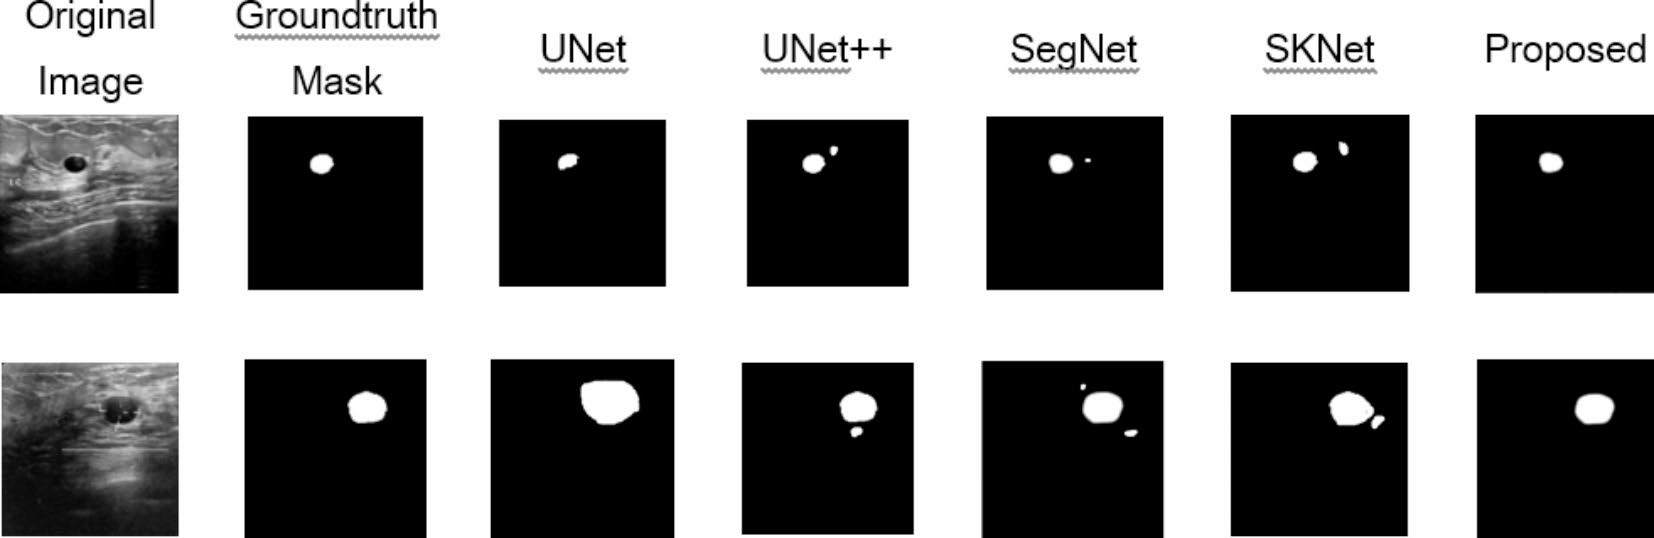

Aşağıdaki kod çalışmadı

In [ ]:
# import nibabel as nib
# import numpy as np
# import matplotlib.pyplot as plt

# # ==========================
# # 1. Dosya yollarını belirt
# # ==========================
# original_path   = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/imagesTs/ispy1_1082_0000.nii.gz"
# gt_path         = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs/ispy1_1082.nii.gz"
# pred_path       = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions/ispy1_1082.nii.gz"

# # ==========================
# # 2. Dosyaları yüklev
# # ==========================
# original_img = nib.load(original_path).get_fdata()
# gt           = nib.load(gt_path).get_fdata()
# pred         = nib.load(pred_path).get_fdata()

# # ==========================
# # 3. Slice seçimi
# # ==========================
# # Orijinal görüntünün boyutunu yazdıralım
# print("Orijinal görüntü boyutları (x, y, z):", original_img.shape)

# # Kullanıcıdan slice seçimi (z ekseni üzerinden)
# slice_idx = int(input(f"Bir slice seç (0 - {original_img.shape[2]-1} arası): "))

# # ==========================
# # 4. Görselleri hazırla
# # ==========================
# images = [
#     original_img[:, :, slice_idx],
#     gt[:, :, slice_idx],
#     pred[:, :, slice_idx],
# ]

# titles = ["Original Image", "Groundtruth", "Prediction"]

# # ==========================
# # 5. Görselleştirme
# # ==========================
# plt.figure(figsize=(12, 4))
# for i in range(len(images)):
#     plt.subplot(1, len(images), i+1)
#     plt.imshow(images[i], cmap="gray")
#     plt.title(titles[i], fontsize=10)
#     plt.axis("off")

# plt.tight_layout()
# plt.show()


Orijinal görüntü boyutları (x, y, z): (256, 256, 64)
Bir slice seç (0 - 63 arası): 35


In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

# ============ Dosya yolları ============
original_path = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/imagesTs/ispy1_1082_0000.nii.gz"
gt_path       = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs/ispy1_1082.nii.gz"
pred_path     = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_postprocessed/ispy1_1082_postprocessed.nii.gz"

# ============ Verileri yükle ============
original_img = nib.load(original_path).get_fdata()
gt = nib.load(gt_path).get_fdata()
pred = nib.load(pred_path).get_fdata()

# ============ Slice seçimi ============
slice_idx = int(input(f"Bir slice seç (0 - {original_img.shape[2]-1} arası): "))

# ============ Normalize + Binary ============
def normalize(img):
    img = img.astype(float)
    return (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)

ori  = normalize(original_img[:, :, slice_idx])
mask = gt[:, :, slice_idx]
seg  = pred[:, :, slice_idx]

# ============ Görseller ============
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1. Orijinal
axes[0].imshow(ori, cmap='gray')
axes[0].set_title("Original Image", fontsize=10)
axes[0].axis("off")

# 2. Ground Truth Mask (beyaz arka plan siyah)
axes[1].imshow(mask, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Ground Truth Mask", fontsize=10)
axes[1].axis("off")

# 3. Prediction (nnUNet sonucu)
axes[2].imshow(seg, cmap='gray', vmin=0, vmax=1)
axes[2].set_title("nnU-Net Prediction", fontsize=10)
axes[2].axis("off")

plt.tight_layout()
plt.show()

# ============ PNG olarak kaydet ============
os.makedirs("/content/drive/MyDrive/nnUNet_visuals", exist_ok=True)
out_path = f"/content/drive/MyDrive/nnUNet_visuals/ispy1_1082_slice{slice_idx}.png"
fig.savefig(out_path, bbox_inches="tight", dpi=300)
print(f"✅ Görsel kaydedildi: {out_path}")


Bir slice seç (0 - 63 arası): 35
✅ Görsel kaydedildi: /content/drive/MyDrive/nnUNet_visuals/ispy1_1082_slice35.png


Orijinal görüntü boyutları: (256, 256, 64)
Label boyutları: (256, 256, 64)
Prediction boyutları: (256, 256, 64)
Bir slice seç (0 - 63 arası): 35


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


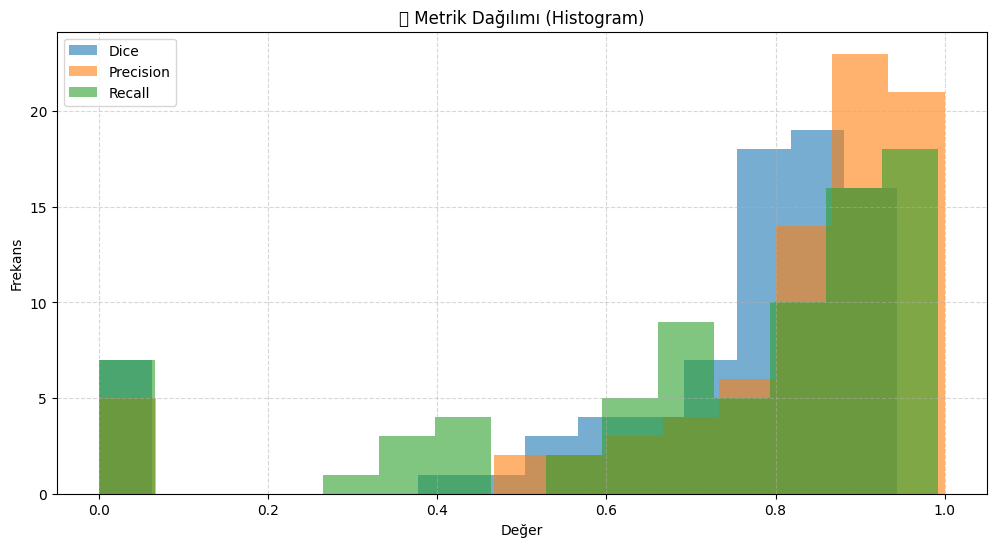

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


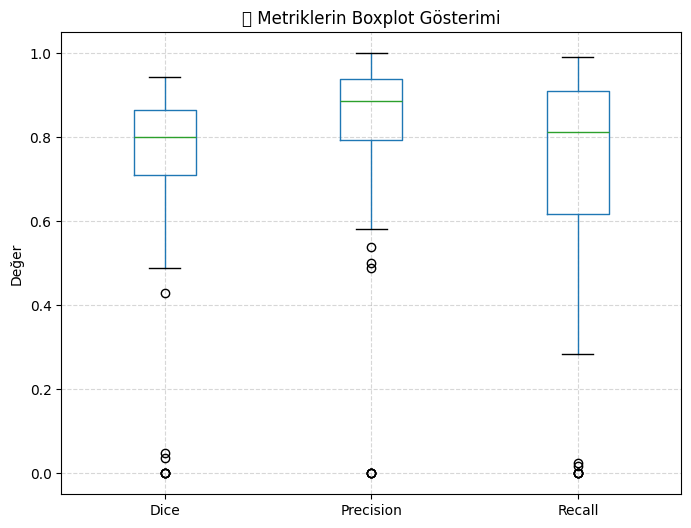

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


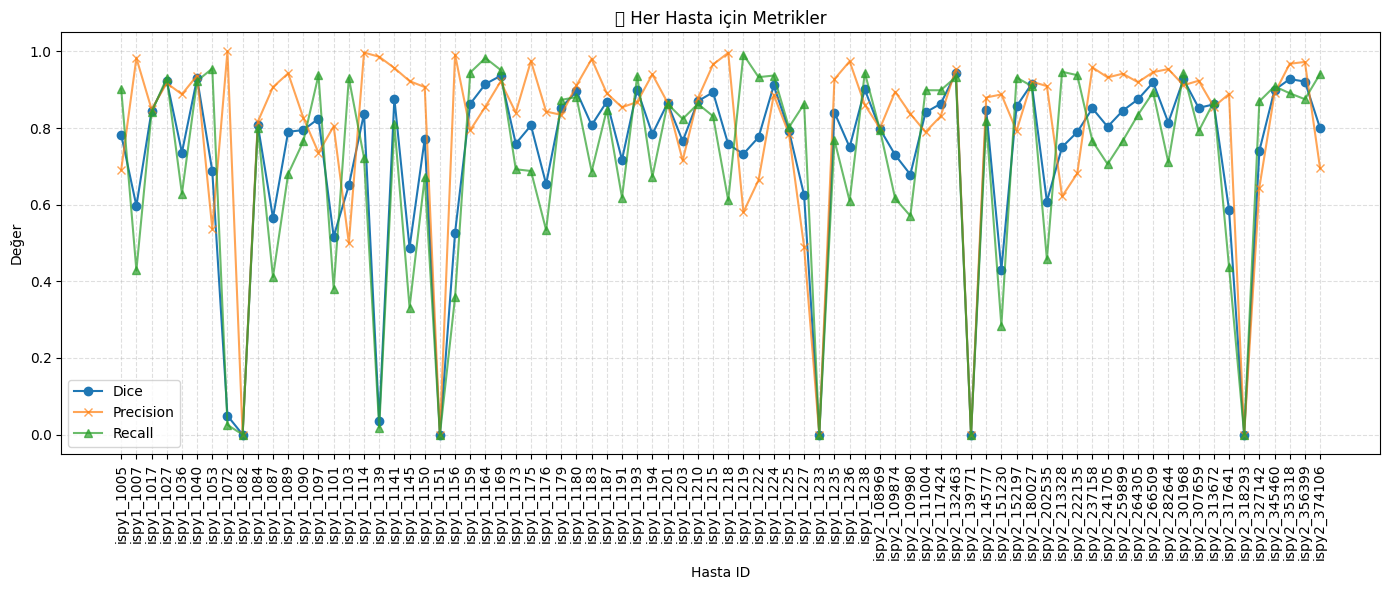

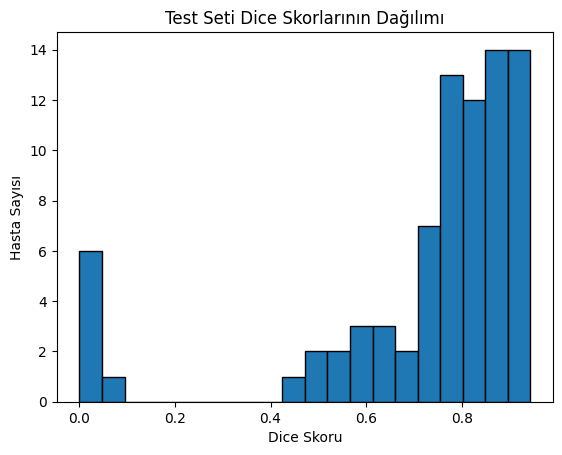

<Figure size 1200x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

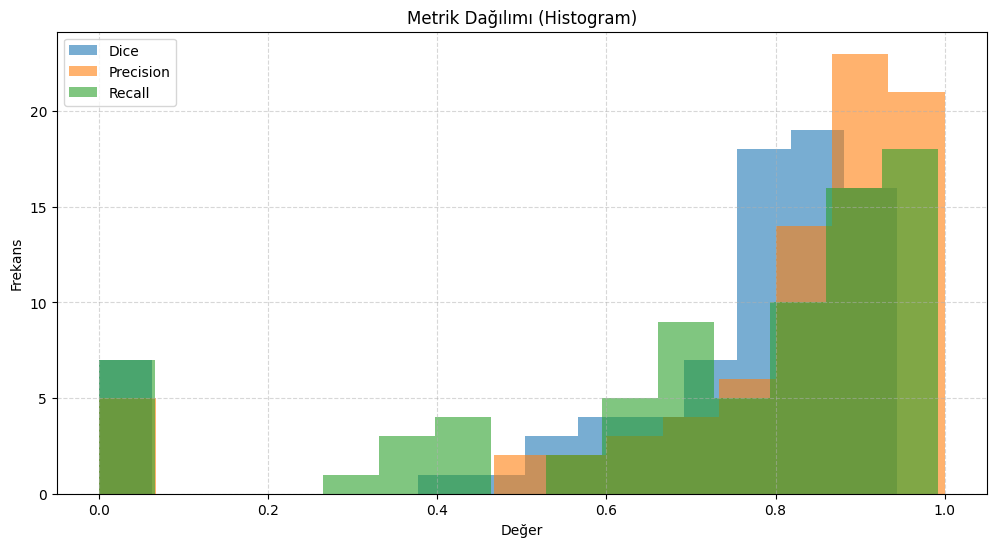

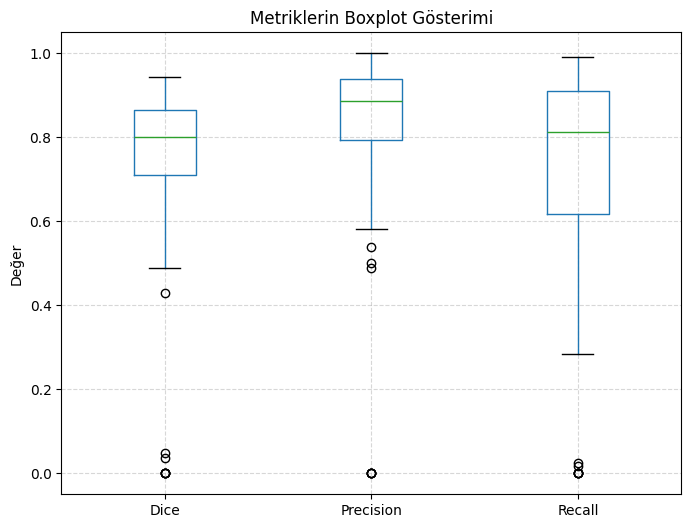

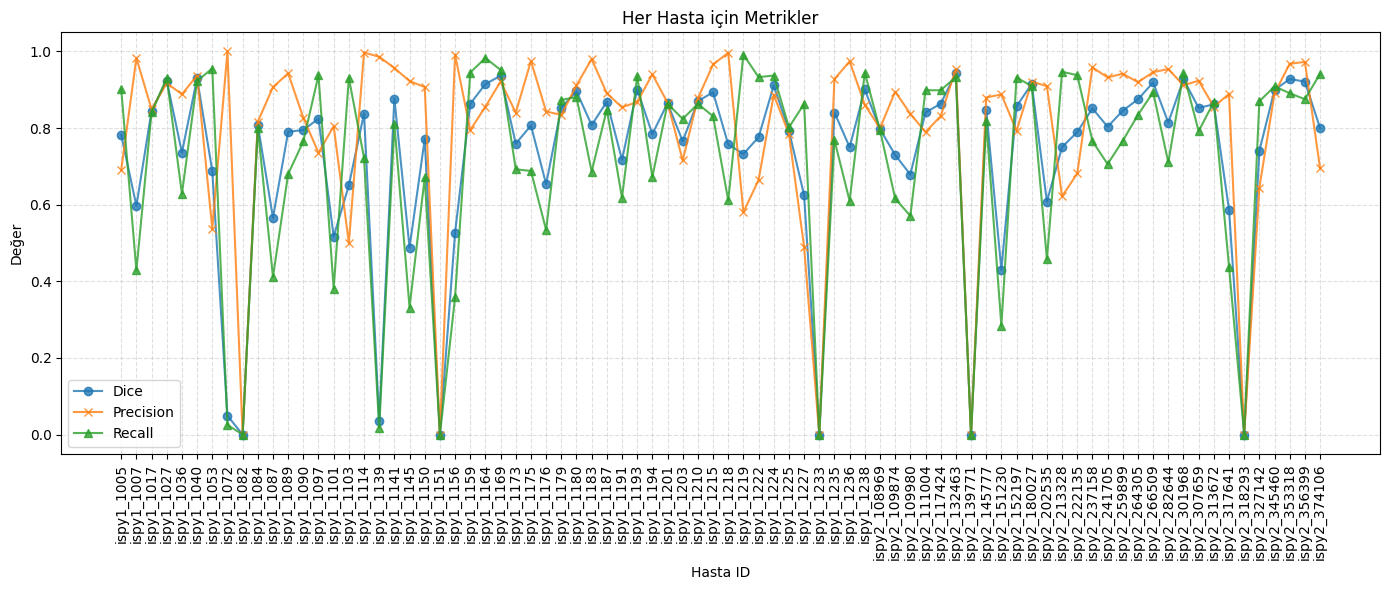

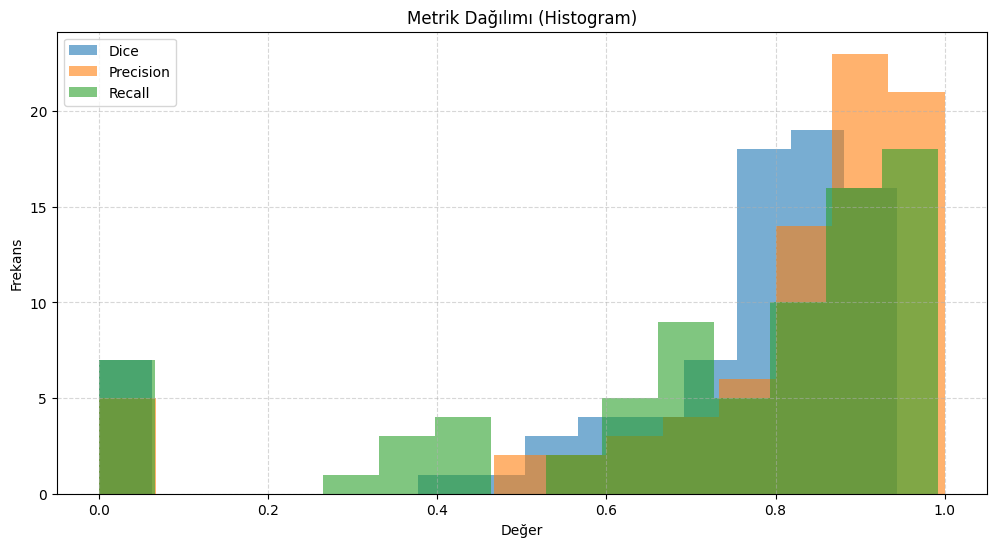

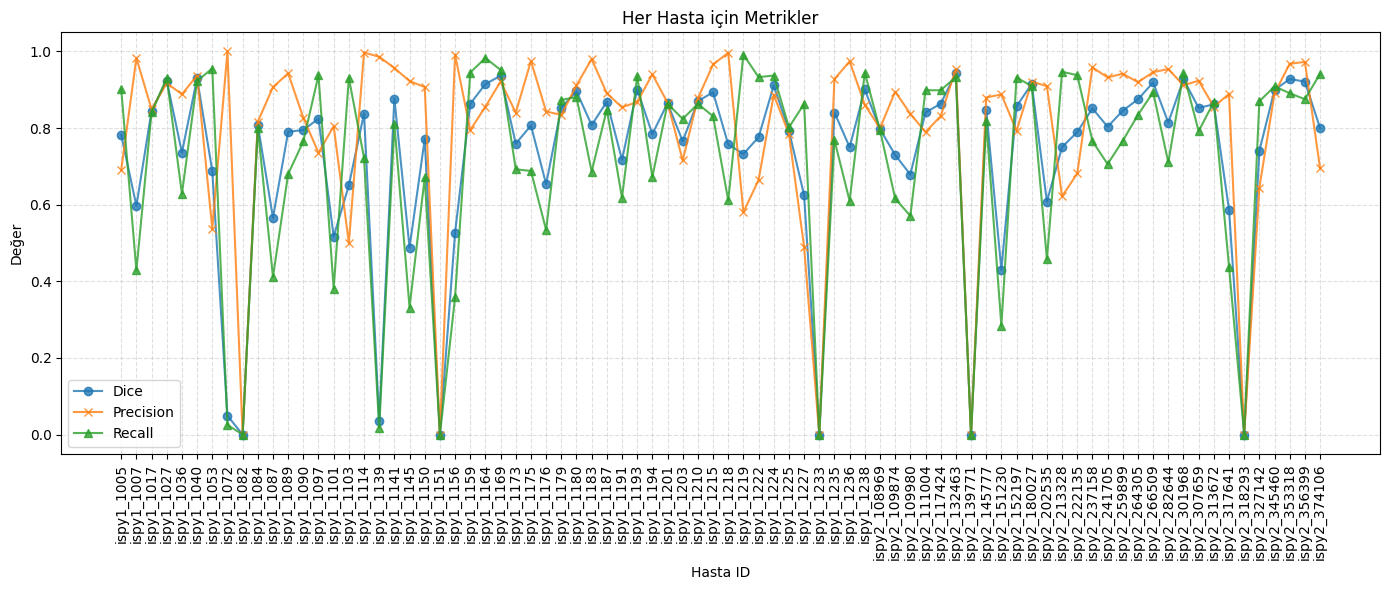

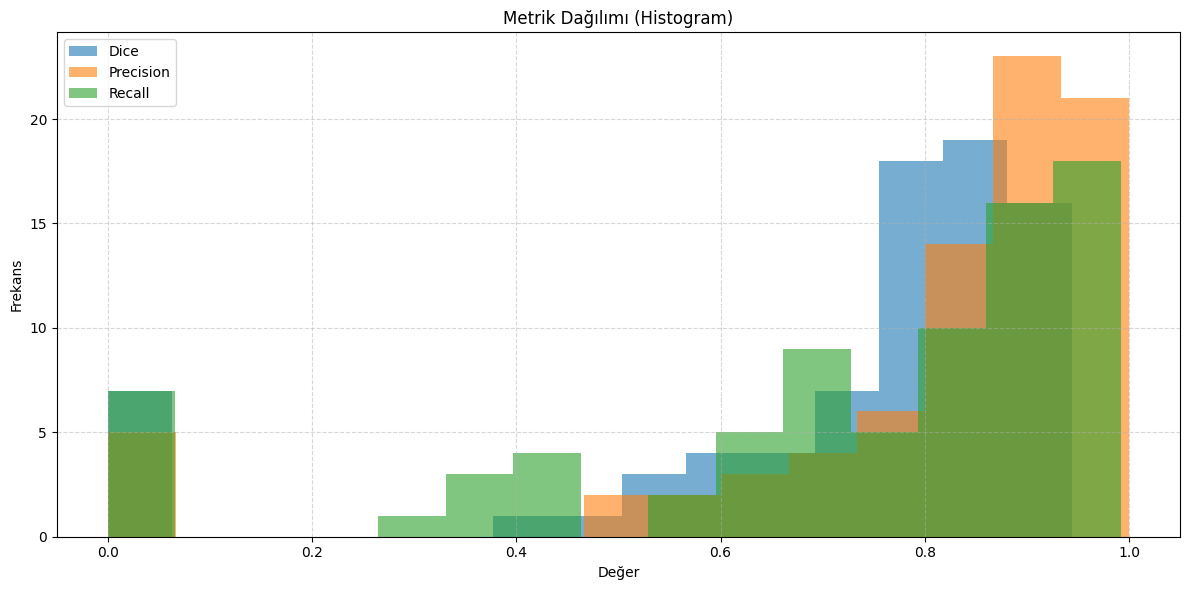

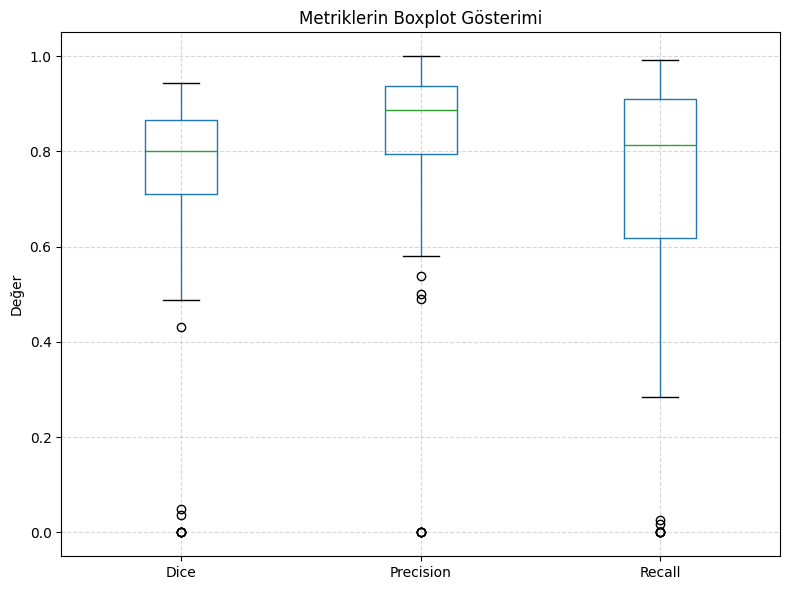

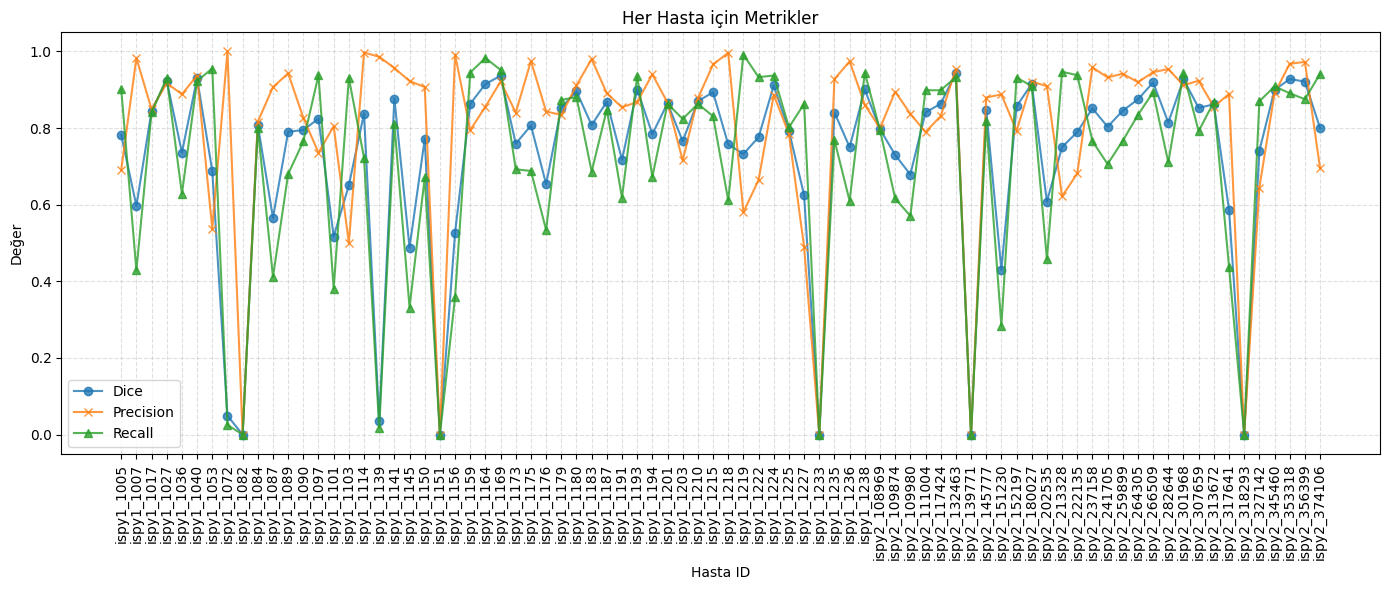

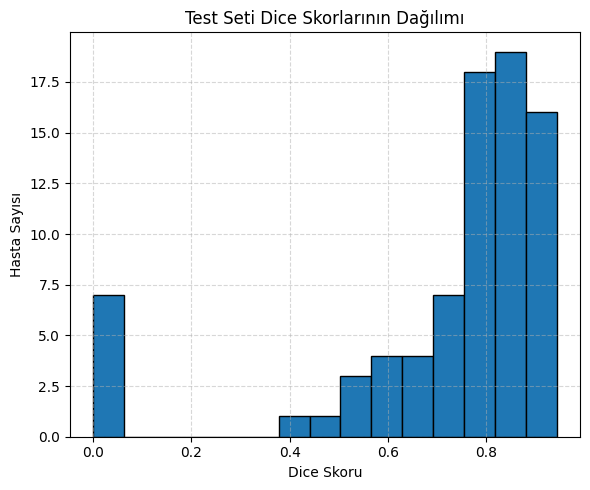

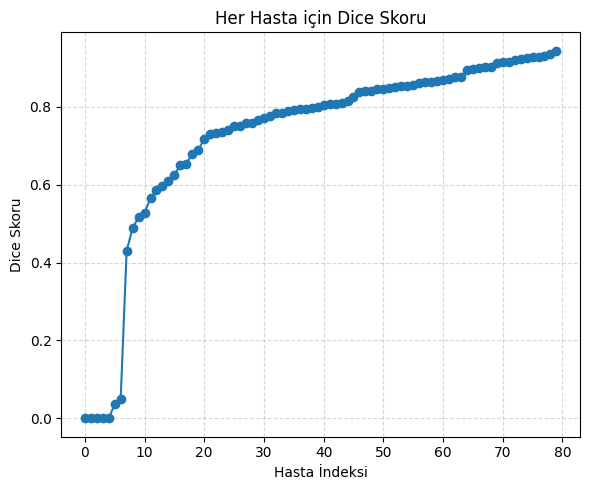

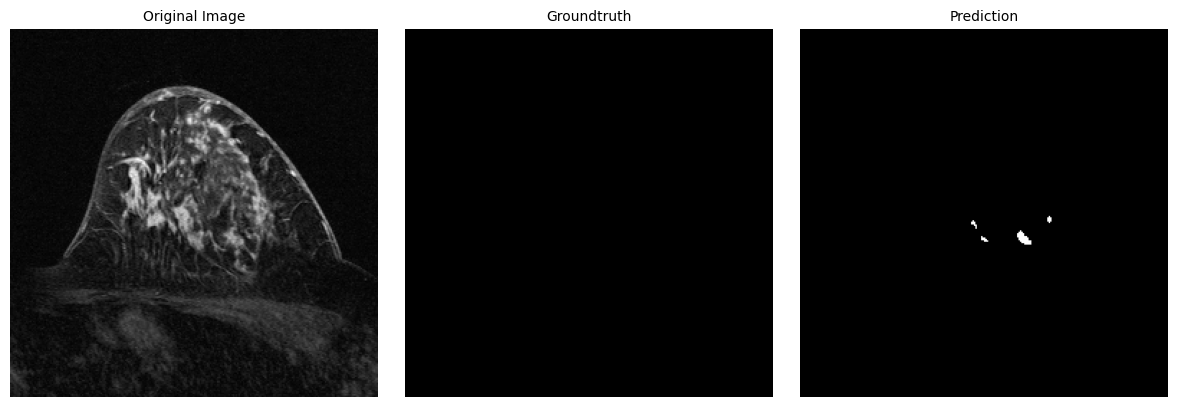

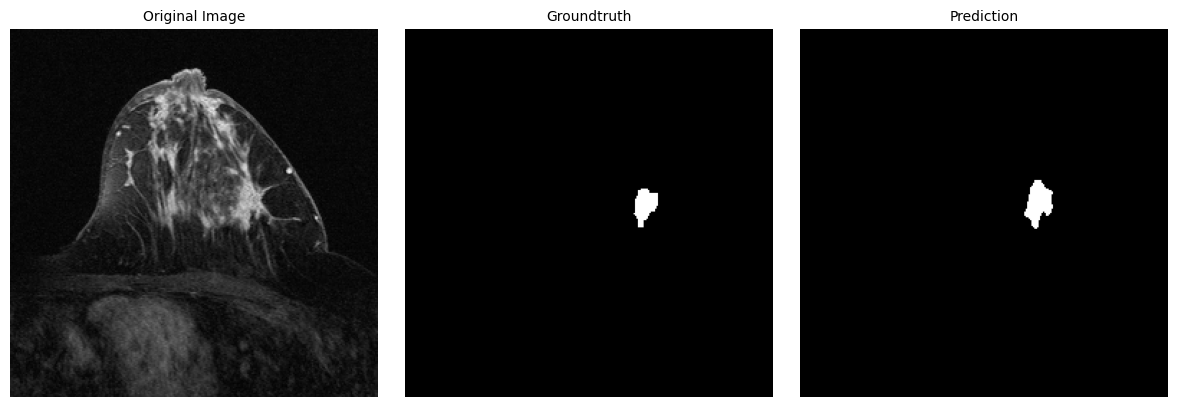

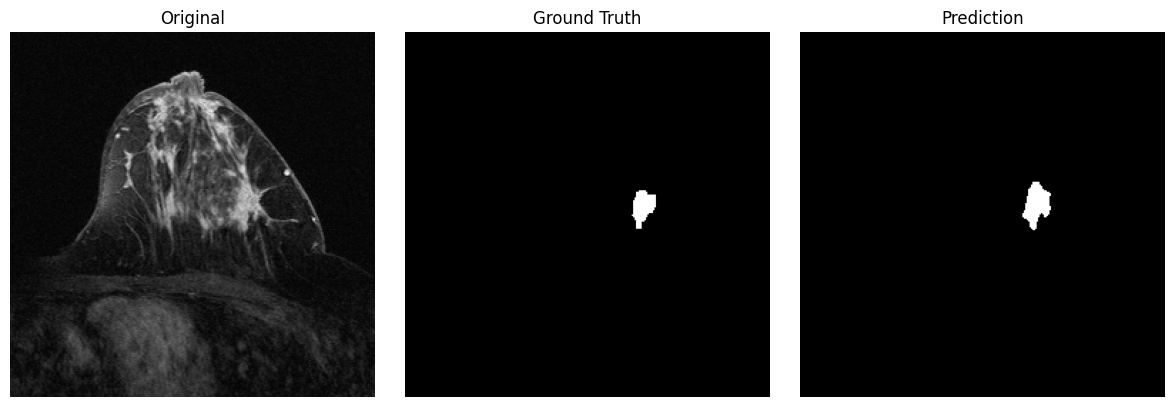

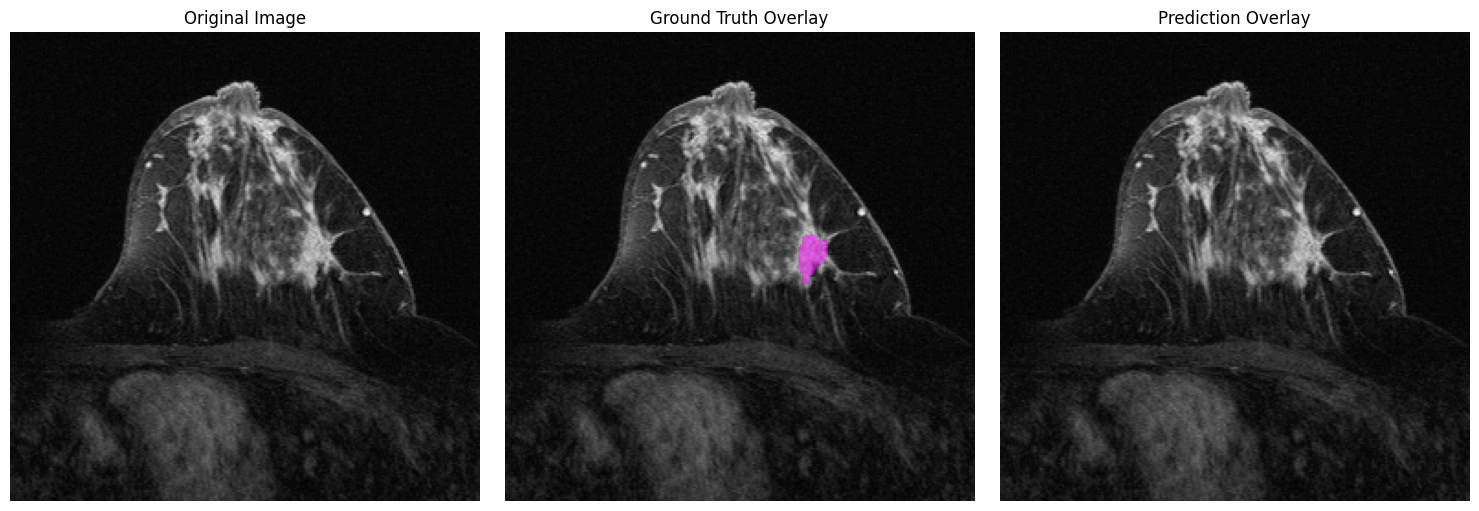

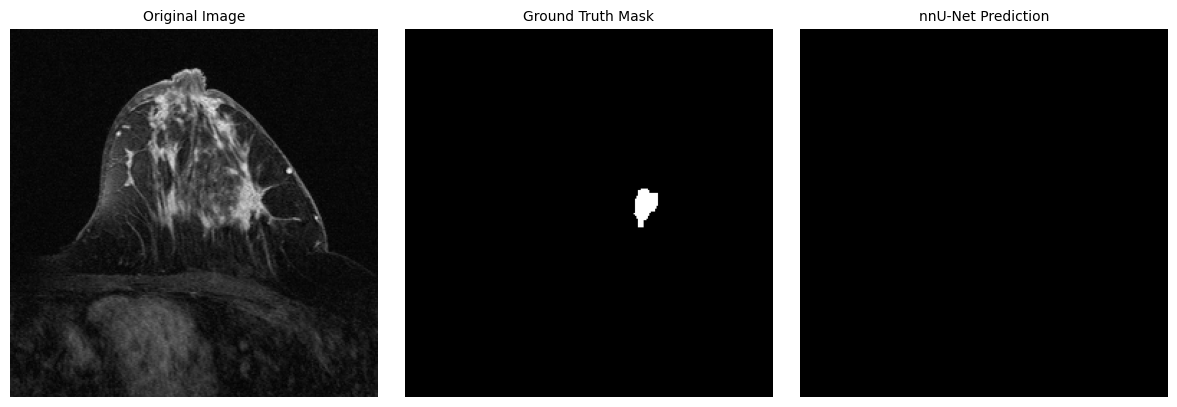

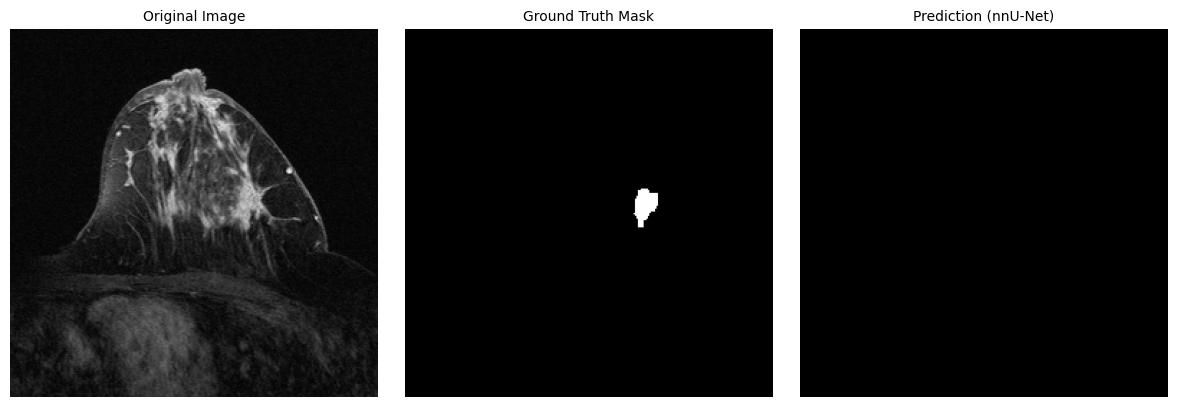

✅ Görsel kaydedildi: /content/drive/MyDrive/nnUNet_visuals/ispy1_1082_slice35.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# ✅ Görselin her koşulda ekrana bastırılması için:
%matplotlib inline
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

# ============ Dosya yolları ============
original_path = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/imagesTs/ispy1_1082_0000.nii.gz"
gt_path       = "/content/drive/MyDrive/nnUNet_raw_data/Dataset001_MyTestTask/labelsTs/ispy1_1082.nii.gz"
pred_path     = "/content/drive/MyDrive/nnUNet_trained_models/Dataset001_MyTestTask/test_predictions_postprocessed/ispy1_1082_postprocessed.nii.gz"

# ============ Verileri yükle ============
original_img = nib.load(original_path).get_fdata()
gt = nib.load(gt_path).get_fdata()
pred = nib.load(pred_path).get_fdata()

print("Orijinal görüntü boyutları:", original_img.shape)
print("Label boyutları:", gt.shape)
print("Prediction boyutları:", pred.shape)

# ============ Slice seçimi ============
slice_idx = int(input(f"Bir slice seç (0 - {original_img.shape[2]-1} arası): "))

# ============ Normalize fonksiyonu ============
def normalize(img):
    img = img.astype(float)
    return (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)

# ============ Seçilen slice'ları çıkar ============
ori  = normalize(original_img[:, :, slice_idx])
mask = gt[:, :, slice_idx]
seg  = pred[:, :, slice_idx]

# ============ Görselleştirme ============
plt.figure(figsize=(12, 4))

# 1️⃣ Orijinal
plt.subplot(1, 3, 1)
plt.imshow(ori, cmap='gray')
plt.title("Original Image", fontsize=10)
plt.axis("off")

# 2️⃣ Ground Truth
plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray', vmin=0, vmax=1)
plt.title("Ground Truth Mask", fontsize=10)
plt.axis("off")

# 3️⃣ Prediction
plt.subplot(1, 3, 3)
plt.imshow(seg, cmap='gray', vmin=0, vmax=1)
plt.title("Prediction (nnU-Net)", fontsize=10)
plt.axis("off")

plt.tight_layout()

# 🚀 Zorla ekrana çiz
plt.show(block=False)
plt.pause(1)

# ============ PNG olarak kaydet ============
os.makedirs("/content/drive/MyDrive/nnUNet_visuals", exist_ok=True)
out_path = f"/content/drive/MyDrive/nnUNet_visuals/ispy1_1082_slice{slice_idx}.png"
plt.savefig(out_path, bbox_inches="tight", dpi=300)
print(f"✅ Görsel kaydedildi: {out_path}")
